In [1]:
import os
import shutil
from concurrent.futures import ProcessPoolExecutor, as_completed
from tempfile import mkdtemp

import cv2
import imagehash
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

# -------------------------
# Config
# -------------------------
DATA_ROOT = "../data"
TRAIN_IMG_DIR = os.path.join(DATA_ROOT, "train_data")
TRAIN_MSK_DIR = os.path.join(DATA_ROOT, "train_data")

PATCH_SIZE = 384
N_PATCHES = 16                  # patches per slide

MARGIN = 16                     # bbox margin (optional use later)

MASK_PATCH_FRAC = 0.75          # fraction of patches that should be mask-driven
MIN_MASK_PIXELS_SLIDE = 50      # if slide mask has fewer pixels -> treat as "no mask"
MIN_MASK_IN_PATCH = 30          # mask pixels required in a "mask" patch
MIN_TISSUE_FRAC = 0.07          # tissue fraction required to accept a patch
MIN_PATCH_PER_SLIDE = 4

MIN_CENTER_DIST = PATCH_SIZE // 2
MAX_TRIES_PER_SLIDE = 10      # hard cap to prevent infinite loops
MAX_TRIES_PER_PATCH = 5        # local tries before relaxing constraints


OUT_DIR = os.path.join("processed", "numpy_patches")
os.makedirs(OUT_DIR, exist_ok=True)

# class mapping
CLASS2ID: dict[str, int] = {"Luminal A": 0, "Luminal B": 1, "HER2(+)": 2, "Triple negative": 3}
ID2CLASS: dict[int, str] = {0:"Luminal A", 1:"Luminal B", 2:"HER2(+)", 3:"Triple negative"}

# assertions
assert os.path.exists(TRAIN_IMG_DIR), f"Train image dir not found: {TRAIN_IMG_DIR}"
assert os.path.exists(TRAIN_MSK_DIR), f"Train mask dir not found: {TRAIN_MSK_DIR}"
for key, val in CLASS2ID.items():
    assert ID2CLASS[val] == key, "CLASS2ID and ID2CLASS mismatch for class " + key

In [2]:
# -------------------------
# DataFrame cleanup
# -------------------------
def cleanup_train_labels(df: pd.DataFrame) -> pd.DataFrame:
    """
    Remove entries from df where the corresponding image file does not exist.
    :param df: DataFrame with at least a "sample_index" column
    :return: Cleaned DataFrame
    """
    to_drop = []
    for idx, row in df.iterrows():
        sample_index = row["sample_index"]
        img_path = os.path.join(TRAIN_IMG_DIR, sample_index)
        if not os.path.exists(img_path):
            to_drop.append(idx)
    df = df.drop(to_drop).reset_index(drop=True)
    return df

In [3]:
# -------------------------
# IO helpers
# -------------------------
def read_rgb(path: str) -> np.ndarray:
    bgr = cv2.imread(path, cv2.IMREAD_COLOR)
    if bgr is None:
        raise FileNotFoundError(path)
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

def read_mask(path: str) -> np.ndarray:
    m = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if m is None:
        raise FileNotFoundError(path)
    return (m > 0).astype(np.uint8)


# -------------------------
# Geometry helpers
# -------------------------
def clamp_center(cx, cy, w, h, half):
    cx = int(np.clip(cx, half, w - half - 1))
    cy = int(np.clip(cy, half, h - half - 1))
    return cx, cy

def crop_patch(img, cx, cy, ps):
    half = ps // 2
    x0, x1 = cx - half, cx + half
    y0, y1 = cy - half, cy + half
    return img[y0:y1, x0:x1]

def far_enough(cx, cy, centers, min_dist_sq: int) -> bool:
    for x, y in centers:
        if (cx - x) * (cx - x) + (cy - y) * (cy - y) < min_dist_sq:
            return False
    return True

def box_from_center(cx, cy, half):
    return (cx-half, cy-half, cx+half, cy+half)

def iou(a, b):
    ax0, ay0, ax1, ay1 = a
    bx0, by0, bx1, by1 = b
    ix0, iy0 = max(ax0, bx0), max(ay0, by0)
    ix1, iy1 = min(ax1, bx1), min(ay1, by1)
    iw, ih = max(0, ix1-ix0), max(0, iy1-iy0)
    inter = iw * ih
    if inter == 0: return 0.0
    area_a = (ax1-ax0) * (ay1-ay0)
    area_b = (bx1-bx0) * (by1-by0)
    return inter / (area_a + area_b - inter)

def too_much_overlap(new_box, boxes, max_iou=0.7):
    return any(iou(new_box, b) > max_iou for b in boxes)

# -------------------------
# Robust tissue detector (LAB distance from background)
# -------------------------
def tissue_mask_from_rgb_lab(rgb: np.ndarray) -> np.ndarray:
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB).astype(np.float32)
    h, w = lab.shape[:2]
    b = max(8, min(h, w) // 50)  # adaptive border thickness

    border = np.concatenate([
        lab[:b, :, :].reshape(-1, 3),
        lab[-b:, :, :].reshape(-1, 3),
        lab[:, :b, :].reshape(-1, 3),
        lab[:, -b:, :].reshape(-1, 3),
    ], axis=0)

    bg_mean = border.mean(axis=0)
    bg_std  = border.std(axis=0) + 1e-6

    d = ((lab - bg_mean) / bg_std) ** 2
    d = d.sum(axis=2)

    # keep top ~10% most "non-background" pixels
    thr = np.percentile(d, 90)
    t = (d > thr).astype(np.uint8)

    top_h = detect_top_shadow_by_step(rgb)
    if top_h > 0:
        t[:top_h, :] = 0

    # optional: keep your bottom band logic if you have it
    top2, bot_h = detect_shadow_bands(rgb)
    if bot_h > 0:
        t[h-bot_h:, :] = 0


    # remove detected shadow bands
#    top_h, bot_h = detect_shadow_bands(rgb)
#    if top_h > 0:
#        t[:top_h, :] = 0
#    if bot_h > 0:
#        t[h-bot_h:, :] = 0

    t = cv2.medianBlur(t, 5)
    kernel = np.ones((5, 5), np.uint8)
    t = cv2.morphologyEx(t, cv2.MORPH_CLOSE, kernel, iterations=1)

    return t

def tissue_fraction(rgb_patch: np.ndarray) -> float:
    return float(tissue_mask_from_rgb_lab(rgb_patch).mean())

def detect_shadow_bands(rgb: np.ndarray, max_frac: float = 0.12):
    """Return (top_h, bot_h) number of rows to ignore as border/shadow."""
    gray = rgb.mean(axis=2).astype(np.float32)
    h = gray.shape[0]
    k = max(10, int(h * max_frac))

    row_mean = gray.mean(axis=1)
    row_std  = gray.std(axis=1)

    # Use interior as reference
    interior = slice(k, h - k) if h > 2*k else slice(h//4, 3*h//4)
    ref_mean = np.median(row_mean[interior])
    ref_std  = np.median(row_std[interior])

    # Shadow rows: very uniform AND significantly darker than interior
    std_thr  = max(3.0, 0.35 * ref_std)
    mean_thr = ref_mean - 0.10 * ref_mean  # 10% darker than interior median

    top_h = 0
    for i in range(k):
        if (row_std[i] < std_thr) and (row_mean[i] < mean_thr):
            top_h += 1
        else:
            break

    bot_h = 0
    for i in range(h-1, h-k-1, -1):
        if (row_std[i] < std_thr) and (row_mean[i] < mean_thr):
            bot_h += 1
        else:
            break

    return top_h, bot_h

def has_top_shadow(patch_rgb: np.ndarray, band=40, mid=80,
                   mean_drop=8.0, std_max=6.0) -> bool:
    """
    Detect scanner shadow band inside a patch: top rows are darker + very uniform.
    band/mid in pixels.
    """
    gray = patch_rgb.mean(axis=2).astype(np.float32)

    h = gray.shape[0]
    band = min(band, h//3)
    mid0 = h//2 - mid//2
    mid1 = h//2 + mid//2

    top = gray[:band, :]
    midp = gray[mid0:mid1, :]

    top_mean = float(top.mean())
    top_std  = float(top.std())
    mid_mean = float(midp.mean())

    # shadow = darker than center AND uniform/smooth
    return (mid_mean - top_mean) > mean_drop and top_std < std_max

def detect_top_shadow_by_step(rgb: np.ndarray, max_frac=0.15):
    gray = rgb.mean(axis=2).astype(np.float32)
    h = gray.shape[0]
    k = max(20, int(h * max_frac))

    row_mean = gray.mean(axis=1)
    row_mean_s = cv2.GaussianBlur(row_mean.reshape(-1,1), (1, 31), 0).ravel()

    # derivative: big positive jump means leaving dark band
    d = np.diff(row_mean_s[:k])
    j = int(np.argmax(d))  # location of strongest upward step

    # validate: require meaningful jump
    if d[j] < 2.5:   # tweak (2–6) depending on slides
        return 0

    # take a small safety margin
    return min(k, j + 5)

# -------------------------
# Mask component sampling
# -------------------------
def get_mask_components(mask: np.ndarray):
    num, labels = cv2.connectedComponents(mask, connectivity=8)
    comps = []
    for k in range(1, num):
        ys, xs = np.where(labels == k)
        if len(xs) > 0:
            comps.append((xs, ys))
    return comps

def sample_from_components(components, rng: np.random.Generator):
    areas = np.array([len(c[0]) for c in components], dtype=np.float64)
    probs = areas / areas.sum()
    idx = rng.choice(len(components), p=probs)
    xs, ys = components[idx]
    j = rng.integers(0, len(xs))
    return int(xs[j]), int(ys[j])

def sample_from_binary(binmask: np.ndarray, rng: np.random.Generator):
    ys, xs = np.where(binmask > 0)
    if len(xs) == 0:
        return None
    j = rng.integers(0, len(xs))
    return int(xs[j]), int(ys[j])

# -------------------------
# Patch hashing (to avoid duplicates)
# -------------------------
def quick_patch_hash(rgb, size=32):
    # very cheap perceptual-ish hash
    small = cv2.resize(rgb, (size, size), interpolation=cv2.INTER_AREA)
    return hash((small.mean(axis=2) > 128).astype(np.uint8).tobytes())

def ahash_u64(rgb_patch, hash_size=8):
    # grayscale + downsample to (hash_size x hash_size)
    gray = (0.299 * rgb_patch[...,0] + 0.587 * rgb_patch[...,1] + 0.114 * rgb_patch[...,2]).astype(np.float32)
    small = gray.reshape(hash_size, rgb_patch.shape[0]//hash_size, hash_size, rgb_patch.shape[1]//hash_size).mean(axis=(1,3))
    bits = small > small.mean()
    # pack into uint64
    h = 0
    for b in bits.flatten():
        h = (h << 1) | int(b)
    return h

def patch_key(patch_rgb, patch_msk, hash_size=16):
    """
    Compute combined hash key for RGB patch and mask patch.
    Returns a tuple of (imagehash for RGB, imagehash for mask).
    """
    # RGB hash
    h_img = imagehash.phash(Image.fromarray(patch_rgb), hash_size=hash_size)

    # Mask hash (squeeze + uint8)
    m = (patch_msk > 0).astype(np.uint8) * 255
    h_msk = imagehash.phash(Image.fromarray(m), hash_size=hash_size)

    return h_img, h_msk


In [4]:
def build_train_numpy(
    df,                         # DataFrame with columns: ["sample_index","label"]
    train_img_dir: str,
    train_msk_dir: str,
    out_dir: str,
    *,
    patch_size: int = 384,
    n_patches: int = 16,
    mask_patch_frac: float = 0.75,
    min_mask_pixels_slide: int = 50,
    min_mask_in_patch: int = 10,          # lowered to avoid deadlocks on tiny masks
    min_tissue_frac: float = 0.07,
    min_dist_tissue: int | None = None,   # default: patch_size//2
    min_dist_mask: int | None = None,     # default: patch_size//4
    max_tries_per_slide: int = 8000,
    max_tries_per_patch: int = 80,
    seed: int = 42,
    class2id: dict | None = None,
):
    """
    Build memmapped numpy patch dataset from slide-level train set.

    - Per slide: extracts `n_patches` patches (uint8 RGB) and associated mask patches (uint8 0/255).
    - Deterministic mask quota + guaranteed termination (hard cap + spill to tissue + optional padding).
    - Robust tissue filter using LAB distance from border-estimated background.

    Expected helpers available in your notebook/script:
      - read_rgb(path) -> (H,W,3) uint8 RGB
      - read_mask(path) -> (H,W) uint8 {0,1} or bool
      - crop_patch(img, cx, cy, patch_size)
      - clamp_center(cx, cy, w, h, half)
      - far_enough(cx, cy, centers, min_dist_sq)
      - get_mask_components(mask) -> list of (xs, ys) arrays for each component
      - sample_from_components(components, rng) -> (cx, cy)
      - sample_from_binary(binmask, rng) -> (cx, cy) or None
      - tissue_mask_from_rgb_lab(rgb) -> (H,W) uint8 {0,1}
      - tissue_fraction(rgb_patch) -> float in [0,1]
    """
    print('[WARNING] This serial version may contain bugs. Please use the parallel version instead.')

    os.makedirs(out_dir, exist_ok=True)
    rng = np.random.default_rng(seed)

    slide_ids = df["sample_index"].tolist()
    y = df["label"].map(class2id).astype(int).to_numpy()

    n_slides = len(slide_ids)
    total_patches = n_slides * n_patches

    # distances
    if min_dist_tissue is None:
        min_dist_tissue = patch_size // 2
    if min_dist_mask is None:
        min_dist_mask = patch_size // 4

    min_dist_sq_tissue = int(min_dist_tissue * min_dist_tissue)
    min_dist_sq_mask = int(min_dist_mask * min_dist_mask)

    # outputs
    x_path = os.path.join(out_dir, f"train_x_uint8_{patch_size}.dat")
    m_path = os.path.join(out_dir, f"train_m_uint8_{patch_size}.dat")
    y_path = os.path.join(out_dir, "train_y_int64.npy")
    idx_path = os.path.join(out_dir, "train_slide_to_patchidx.npy")
    log_path = os.path.join(out_dir, "train_build_log.csv")

    X = np.memmap(x_path, dtype=np.uint8, mode="w+", shape=(total_patches, patch_size, patch_size, 3))
    M = np.memmap(m_path, dtype=np.uint8, mode="w+", shape=(total_patches, patch_size, patch_size, 1))
    slide_to_patchidx = np.zeros((n_slides, 2), dtype=np.int64)

    logs = []
    patch_ptr = 0

    for s, slide_id in tqdm(enumerate(slide_ids), desc="Building memmapped numpy patch dataset from slide-level train set", total=n_slides):
        img_path = os.path.join(train_img_dir, slide_id)
        msk_path = os.path.join(train_msk_dir, slide_id.replace("img", "mask"))

        rgb = read_rgb(img_path)
        msk = read_mask(msk_path).astype(np.uint8)
        if msk.mean() > 0.5:
            msk = 1 - msk

        h, w = rgb.shape[:2]
        half = patch_size // 2

        # Per-slide tissue mask (for tissue sampling)
        tmask = tissue_mask_from_rgb_lab(rgb)

        # Per-slide components
        mask_pixels_slide = int(msk.sum())
        components = get_mask_components(msk) if mask_pixels_slide >= min_mask_pixels_slide else []

        # ---- per-slide quotas (deterministic, but capped by feasibility) ----
        k_mask_target = int(round(n_patches * mask_patch_frac))

        # If mask is basically absent, don't insist on mask patches
        if len(components) == 0:
            k_mask_target = 0
        else:
            # Cap mask quota by "geometric capacity" to prevent deadlocks on tiny/fragmented masks
            # Very conservative: at most ~1 patch per component (you can relax later)
            MAX_PATCHES_PER_COMPONENT = 2
            k_mask_target = min(
                k_mask_target,
                MAX_PATCHES_PER_COMPONENT * len(components)
            )


        # ---- sampling state ----
        centers = []
        boxes = []
        seen_hashes = []
        MAX_DHASH_DIST = 3

        mask_done = 0
        tissue_done = 0
        produced = 0
        tries = 0

        start = patch_ptr

        # ---- sampling loop with hard cap ----
        while produced < n_patches and tries < max_tries_per_slide:
            tries += 1

            # insist on mask until quota met, then tissue
            use_mask = (mask_done < k_mask_target) and (len(components) > 0)

            # if we are stuck trying to satisfy mask quota, spill to tissue early
            if use_mask and tries > (max_tries_per_slide // 5):
                k_mask_target = mask_done
                use_mask = False

            for _ in range(max_tries_per_patch):
                # choose center
                if use_mask:
                    cx, cy = sample_from_components(components, rng)
                else:
                    c = sample_from_binary(tmask, rng)
                    if c is None:
                        cx = int(rng.integers(half, w - half))
                        cy = int(rng.integers(half, h - half))
                    else:
                        cx, cy = c

                cx, cy = clamp_center(cx, cy, w, h, half)

                # distance constraint (looser for mask)
                min_dist_sq_use = min_dist_sq_mask if use_mask else min_dist_sq_tissue
                if not far_enough(cx, cy, centers, min_dist_sq_use):
                    continue

                new_box = box_from_center(cx, cy, half)
                if too_much_overlap(new_box, boxes, max_iou=0.7):
                    continue

                patch_rgb = crop_patch(rgb, cx, cy, patch_size)
                patch_msk = crop_patch(msk, cx, cy, patch_size)

                if patch_rgb.shape[:2] != (patch_size, patch_size):
                    continue

                # reject low-tissue patches
                tmask_patch = crop_patch(tmask, cx, cy, patch_size)  # tmask is 0/1
                if tmask_patch.shape[:2] != (patch_size, patch_size):
                    continue
                tfrac = float(tmask_patch.mean())
                if tfrac < min_tissue_frac:
                    continue

                gray = patch_rgb.mean(axis=2)  # float
                if gray.std() < 5.0:           # tune: 3-10
                    continue


                # if this is a mask patch, require some mask presence
                mask_px = int((patch_msk > 0).sum())
                if use_mask and mask_px < min_mask_in_patch:
                    continue

                # if this is a mask patch, require some mask presence
                mask_px = int((patch_msk > 0).sum())
                if use_mask and mask_px < min_mask_in_patch:
                    continue

                # hard reject duplicates
                ph = imagehash.dhash(Image.fromarray(patch_rgb), hash_size=8)  # 8 => 64-bit hash
                # reject if too similar to any previously accepted patch in this slide
                if any((ph - h) <= MAX_DHASH_DIST for h in seen_hashes):
                    continue
                seen_hashes.append(ph)

                # accept
                centers.append((cx, cy))
                boxes.append(new_box)

                X[patch_ptr] = patch_rgb
                M[patch_ptr, :, :, 0] = (patch_msk > 0).astype(np.uint8) * 255

                patch_ptr += 1
                produced += 1
                if use_mask:
                    mask_done += 1
                else:
                    tissue_done += 1

                break

        end = patch_ptr
        slide_to_patchidx[s] = (start, end)

        status = "ok" if produced == n_patches else "partial"

        # If we couldn't fill, pad with last patch (keeps array shapes consistent)
        if produced < n_patches and produced > 0:
            last_rgb = X[patch_ptr - 1].copy()
            last_msk = M[patch_ptr - 1].copy()
            while produced < n_patches:
                X[patch_ptr] = last_rgb
                M[patch_ptr] = last_msk
                patch_ptr += 1
                produced += 1
            slide_to_patchidx[s] = (start, patch_ptr)
            status = "padded"
            end = patch_ptr

        if produced == 0:
            raise RuntimeError(
                f"Could not extract any patch for slide {slide_id}. "
                f"Try lowering min_tissue_frac/min_mask_in_patch or check tissue detector."
            )

        logs.append({
            "slide_id": slide_id,
            "produced": produced,
            "mask_done": mask_done,
            "tissue_done": tissue_done,
            "mask_pixels_slide": mask_pixels_slide,
            "n_components": len(components),
            "tries": tries,
            "status": status,
            "patch_range_start": int(start),
            "patch_range_end": int(end),
        })

    # Save metadata
    np.save(y_path, y.astype(np.int64))
    np.save(idx_path, slide_to_patchidx)
    pd.DataFrame(logs).to_csv(log_path, index=False)

    X.flush()
    M.flush()

    return {
        "x_path": x_path,
        "m_path": m_path,
        "y_path": y_path,
        "idx_path": idx_path,
        "log_path": log_path,
        "n_slides": n_slides,
        "total_patches": total_patches,
        "patch_size": patch_size,
        "n_patches_per_slide": n_patches,
    }

In [5]:
def _process_one_slide(
    s, slide_id: str, label_id,
    train_img_dir: str, train_msk_dir: str,
    patch_size, n_patches,   # n_patches is now "max target", not mandatory
    mask_patch_frac, min_mask_pixels_slide, min_mask_in_patch,
    min_tissue_frac, min_dist_tissue, min_dist_mask,
    max_tries_per_slide, max_tries_per_patch,
    base_seed,
    tmp_dir: str,
    min_patches_per_slide: int = 1,
):
    rng = np.random.default_rng(base_seed + 1000003 * s)

    img_path = os.path.join(train_img_dir, slide_id)
    msk_path = os.path.join(train_msk_dir, slide_id.replace("img", "mask"))

    rgb = read_rgb(img_path)
    msk = read_mask(msk_path).astype(np.uint8)
    if msk.mean() > 0.5:
        msk = 1 - msk

    h, w = rgb.shape[:2]
    half = patch_size // 2

    if min_dist_tissue is None:
        min_dist_tissue = patch_size // 2
    if min_dist_mask is None:
        min_dist_mask = patch_size // 4
    min_dist_sq_tissue = int(min_dist_tissue * min_dist_tissue)
    min_dist_sq_mask   = int(min_dist_mask * min_dist_mask)

    tmask = tissue_mask_from_rgb_lab(rgb)
    top_h = detect_top_shadow_by_step(rgb)   # compute once per slide

    mask_pixels_slide = int(msk.sum())
    components = get_mask_components(msk) if mask_pixels_slide >= min_mask_pixels_slide else []

    k_mask_target = int(round(n_patches * mask_patch_frac))
    if len(components) == 0:
        k_mask_target = 0
    else:
        MAX_PATCHES_PER_COMPONENT = 2
        k_mask_target = min(k_mask_target, MAX_PATCHES_PER_COMPONENT * len(components))

    # --- VARIABLE outputs ---
    X_list = []
    M_list = []

    centers = []
    boxes = []
    seen_hashes = []
    MAX_DHASH_DIST = 3

    mask_done = 0
    tissue_done = 0
    produced = 0
    tries = 0

    # NOTE: we still "aim" for n_patches but we won't pad if we fail
    while produced < n_patches and tries < max_tries_per_slide:
        tries += 1

        use_mask = (mask_done < k_mask_target) and (len(components) > 0)

        if use_mask and tries > (max_tries_per_slide // 5):
            k_mask_target = mask_done
            use_mask = False

        accepted = False
        for _ in range(max_tries_per_patch):
            if use_mask:
                cx, cy = sample_from_components(components, rng)
            else:
                c = sample_from_binary(tmask, rng)
                if c is None:
                    cx = int(rng.integers(half, w - half))
                    cy = int(rng.integers(half, h - half))
                else:
                    cx, cy = c

            cx, cy = clamp_center(cx, cy, w, h, half)

            # ---- avoid centers that would include top shadow band ----
            if top_h > 0 and (cy - half) < top_h:
                continue

            min_dist_sq_use = min_dist_sq_mask if use_mask else min_dist_sq_tissue
            if not far_enough(cx, cy, centers, min_dist_sq_use):
                continue

            new_box = box_from_center(cx, cy, half)
            if too_much_overlap(new_box, boxes, max_iou=0.7):
                continue

            patch_rgb = crop_patch(rgb, cx, cy, patch_size)
            patch_msk = crop_patch(msk, cx, cy, patch_size)

            if has_top_shadow(patch_rgb):
                continue

            if patch_rgb.shape[:2] != (patch_size, patch_size):
                continue

            tmask_patch = crop_patch(tmask, cx, cy, patch_size)
            if tmask_patch.shape[:2] != (patch_size, patch_size):
                continue
            tissue_frac_patch = float(tmask_patch.mean())
            if tissue_frac_patch < min_tissue_frac:
                continue

            gray = patch_rgb.mean(axis=2)
            if gray.std() < 5.0:
                continue

            mask_px = int((patch_msk > 0).sum())
            if use_mask and mask_px < min_mask_in_patch:
                continue

            ph = imagehash.dhash(Image.fromarray(patch_rgb), hash_size=8)
            if any((ph - hsh) <= MAX_DHASH_DIST for hsh in seen_hashes):
                continue
            seen_hashes.append(ph)

            # accept
            centers.append((cx, cy))
            boxes.append(new_box)

            X_list.append(patch_rgb.astype(np.uint8))
            M_list.append(((patch_msk > 0).astype(np.uint8) * 255)[:, :, None])

            produced += 1
            if use_mask:
                mask_done += 1
            else:
                tissue_done += 1

            accepted = True
            break

        if not accepted:
            # optional relax to avoid deadlocks
            if len(centers) > 8:
                centers = centers[-8:]
            if not use_mask:
                min_dist_sq_tissue = max(min_dist_sq_tissue // 2, (patch_size // 8) ** 2)
            else:
                min_dist_sq_mask = max(min_dist_sq_mask // 2, (patch_size // 16) ** 2)

    if produced < min_patches_per_slide:
        raise RuntimeError(f"Could not extract enough patches for slide {slide_id} (produced={produced})")

    # stack variable
    X_block = np.stack(X_list, axis=0)
    M_block = np.stack(M_list, axis=0)

    # write to temp file (avoid returning big arrays through IPC)
    tmp_path: str = os.path.join(tmp_dir, f"slide_{s:06d}.npz")
    np.savez(tmp_path, X=X_block, M=M_block)

    log_row: dict[str, str | int] = {
        "slide_id": slide_id,
        "produced": int(produced),
        "mask_done": int(mask_done),
        "tissue_done": int(tissue_done),
        "mask_pixels_slide": int(mask_pixels_slide),
        "n_components": int(len(components)),
        "tries": int(tries),
        "status": "ok" if produced == n_patches else "partial",
        # patch_range_* will be filled in finalize phase
    }

    return s, tmp_path, log_row


def build_train_numpy_parallel(
        df: pd.DataFrame,
        train_img_dir: str,
        train_msk_dir: str,
        out_dir: str,
        class2id: dict[str, int],
        *,
        patch_size: int = 384,
        n_patches: int = 16,
        mask_patch_frac: float = 0.75,
        min_mask_pixels_slide: int = 50,
        min_mask_in_patch: int = 10,
        min_tissue_frac: float = 0.07,
        min_dist_tissue: int | None = None,
        min_dist_mask: int | None = None,
        max_tries_per_slide: int = 8000,
        max_tries_per_patch: int = 80,
        seed: int = 42,
        n_workers: int = None,
        min_patches_per_slide: int = 1,
):
    os.makedirs(out_dir, exist_ok=True)

    slide_ids = df["sample_index"].tolist()
    y = df["label"].map(class2id).astype(int).to_numpy()
    n_slides = len(slide_ids)

    if min_dist_tissue is None:
        min_dist_tissue = patch_size // 2
    if min_dist_mask is None:
        min_dist_mask = patch_size // 4

    # final outputs
    x_path = os.path.join(out_dir, f"train_x_uint8_{patch_size}.dat")
    m_path = os.path.join(out_dir, f"train_m_uint8_{patch_size}.dat")
    y_path = os.path.join(out_dir, "train_y_int64.npy")
    idx_path = os.path.join(out_dir, "train_slide_to_patchidx.npy")
    log_path = os.path.join(out_dir, "train_build_log.csv")

    n_workers = n_workers or max(1, (os.cpu_count() or 2) - 1)

    tmp_dir = mkdtemp(prefix="patch_build_tmp_")

    try:
        results: list[None | tuple] = [None] * n_slides  # (tmp_path, log_row, produced)
        logs = []

        with ProcessPoolExecutor(max_workers=n_workers) as ex:
            futures = [
                ex.submit(
                    _process_one_slide,
                    s, slide_id, int(y[s]),
                    train_img_dir, train_msk_dir,
                    patch_size, n_patches,
                    mask_patch_frac, min_mask_pixels_slide, min_mask_in_patch,
                    min_tissue_frac, min_dist_tissue, min_dist_mask,
                    max_tries_per_slide, max_tries_per_patch,
                    seed,
                    tmp_dir,
                    min_patches_per_slide,
                )
                for s, slide_id in enumerate(slide_ids)
            ]

            pbar = tqdm(as_completed(futures), total=len(futures),
                        desc="Extracting patches (per slide)", unit="slide")

            for fut in pbar:
                s, tmp_path, log_row = fut.result()
                # read produced without loading X/M fully? easiest: load header now
                with np.load(tmp_path) as z:
                    produced = int(z["X"].shape[0])

                results[s] = (tmp_path, log_row, produced)
                logs.append(log_row)

                pbar.set_postfix({
                    "avg_patches": f"{np.mean([r[2] for r in results if r is not None]):.1f}"
                })

        # ---- finalize: allocate exact-size memmaps ----
        produced_counts = np.array([results[s][2] for s in range(n_slides)], dtype=np.int64)
        offsets = np.zeros(n_slides + 1, dtype=np.int64)
        offsets[1:] = np.cumsum(produced_counts)
        total_patches = int(offsets[-1])

        X = np.memmap(x_path, dtype=np.uint8, mode="w+", shape=(total_patches, patch_size, patch_size, 3))
        M = np.memmap(m_path, dtype=np.uint8, mode="w+", shape=(total_patches, patch_size, patch_size, 1))
        slide_to_patchidx = np.zeros((n_slides, 2), dtype=np.int64)

        # ---- copy temp blocks into final arrays ----
        for s in tqdm(range(n_slides), desc="Writing final memmaps", unit="slide"):
            start = int(offsets[s])
            end = int(offsets[s + 1])

            tmp_path, log_row, produced = results[s]
            with np.load(tmp_path) as z:
                X[start:end] = z["X"]
                M[start:end] = z["M"]

            slide_to_patchidx[s] = (start, end)

            # fill ranges in logs
            log_row["patch_range_start"] = start
            log_row["patch_range_end"] = end

        # Save metadata
        np.save(y_path, y.astype(np.int64))
        np.save(idx_path, slide_to_patchidx)
        pd.DataFrame(logs).to_csv(log_path, index=False)

        X.flush()
        M.flush()

        return {
            "x_path": x_path,
            "m_path": m_path,
            "y_path": y_path,
            "idx_path": idx_path,
            "log_path": log_path,
            "n_slides": n_slides,
            "total_patches": total_patches,
            "patch_size": patch_size,
            "n_patches_target": n_patches,
            "avg_patches_per_slide": float(produced_counts.mean()),
        }

    finally:
        shutil.rmtree(tmp_dir, ignore_errors=True)

# build the dataset
train_csv_path = os.path.join(DATA_ROOT, "train_labels.csv")
df = cleanup_train_labels(pd.read_csv(train_csv_path))
build_train_numpy_parallel(
    df=df,
    train_img_dir=TRAIN_IMG_DIR,
    train_msk_dir=TRAIN_MSK_DIR,
    out_dir=OUT_DIR,
    class2id=CLASS2ID,
    patch_size=PATCH_SIZE,
    n_patches=N_PATCHES,
    mask_patch_frac=MASK_PATCH_FRAC,
    min_mask_pixels_slide=MIN_MASK_PIXELS_SLIDE,
    min_mask_in_patch=MIN_MASK_IN_PATCH,
    min_tissue_frac=MIN_TISSUE_FRAC,
    max_tries_per_slide=MAX_TRIES_PER_SLIDE,
    seed=42,
    min_patches_per_slide=MIN_PATCH_PER_SLIDE
)

Writing final memmaps: 100%|██████████| 581/581 [00:02<00:00, 193.68slide/s]


{'x_path': 'processed/numpy_patches/train_x_uint8_384.dat',
 'm_path': 'processed/numpy_patches/train_m_uint8_384.dat',
 'y_path': 'processed/numpy_patches/train_y_int64.npy',
 'idx_path': 'processed/numpy_patches/train_slide_to_patchidx.npy',
 'log_path': 'processed/numpy_patches/train_build_log.csv',
 'n_slides': 581,
 'total_patches': 5122,
 'patch_size': 384,
 'n_patches_target': 16,
 'avg_patches_per_slide': 8.815834767641997}

In [6]:
x_path = os.path.join(OUT_DIR, f"train_x_uint8_{PATCH_SIZE}.dat")
m_path = os.path.join(OUT_DIR, f"train_m_uint8_{PATCH_SIZE}.dat")
y_path = os.path.join(OUT_DIR, "train_y_int64.npy")
idx_path = os.path.join(OUT_DIR, "train_slide_to_patchidx.npy")

# Load metadata
slide_to_patchidx = np.load(idx_path)
y = np.load(y_path)

# Infer total patches from slide_to_patchidx
total_patches = int(slide_to_patchidx[-1, 1])

# Open memmaps
X = np.memmap(x_path, dtype=np.uint8, mode="r", shape=(total_patches, PATCH_SIZE, PATCH_SIZE, 3))
M = np.memmap(m_path, dtype=np.uint8, mode="r", shape=(total_patches, PATCH_SIZE, PATCH_SIZE, 1))

print("total_patches:", total_patches, "n_slides:", len(slide_to_patchidx))


total_patches: 5122 n_slides: 581


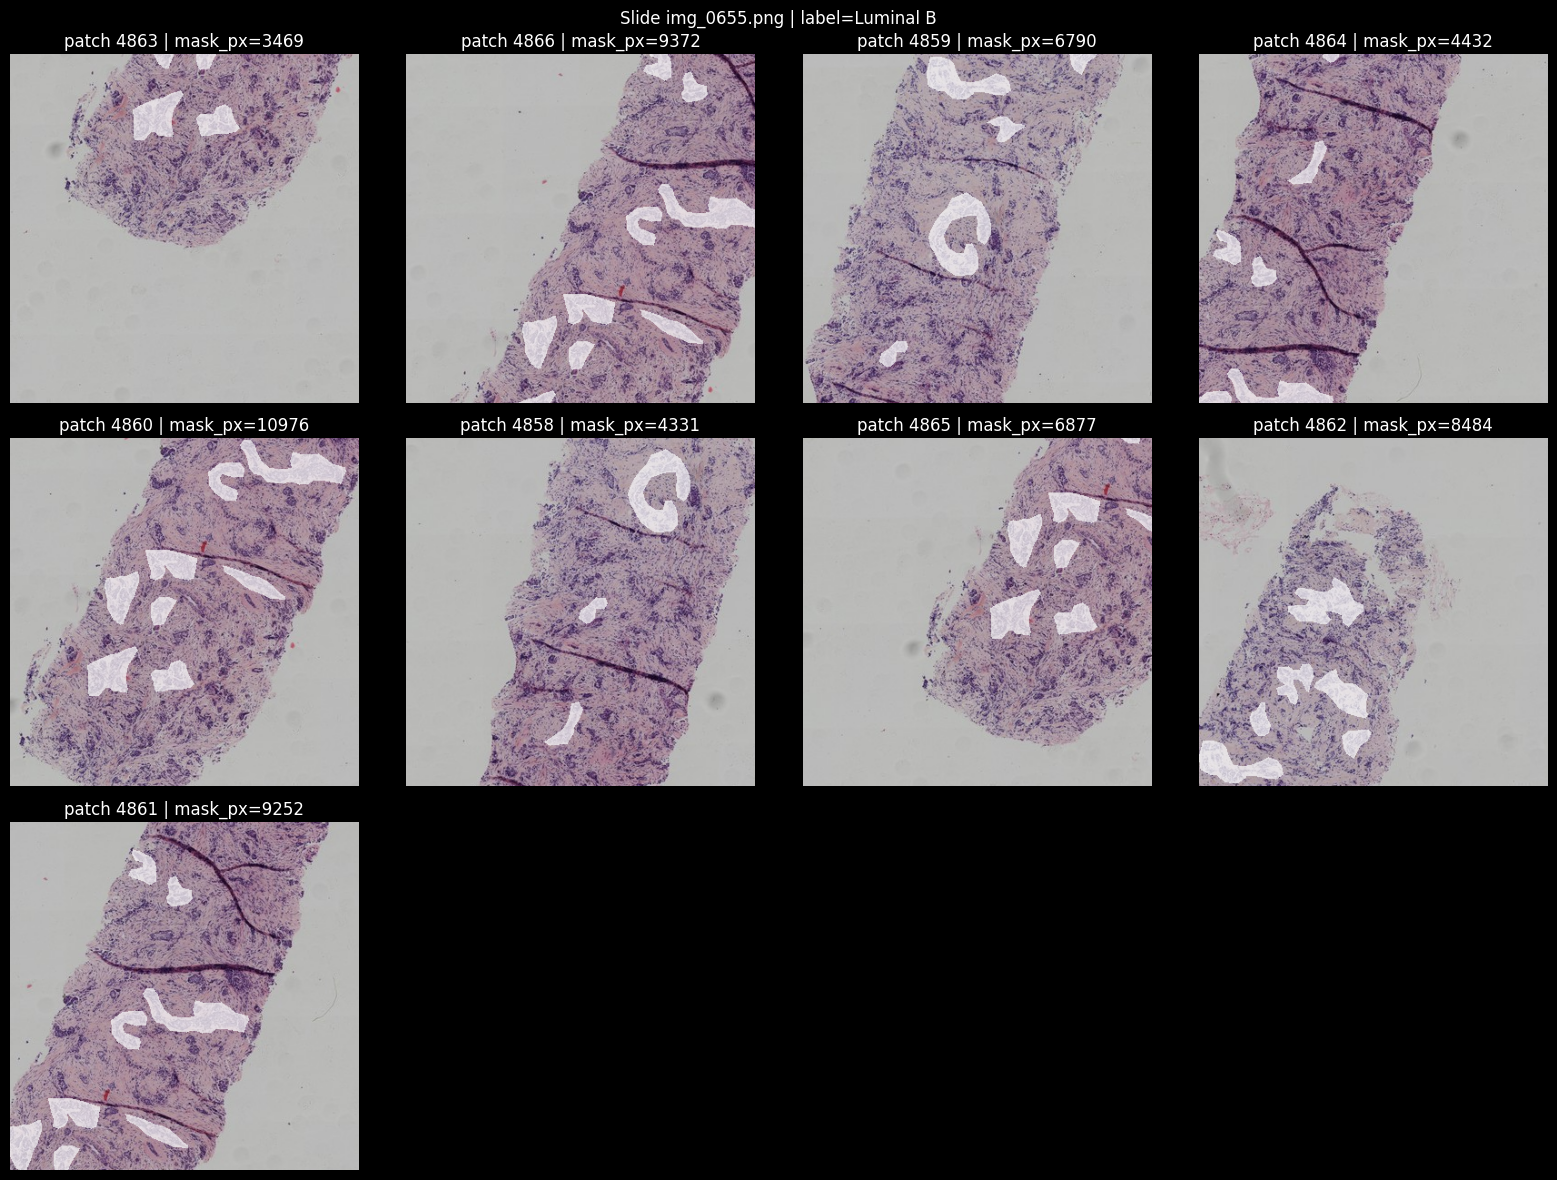

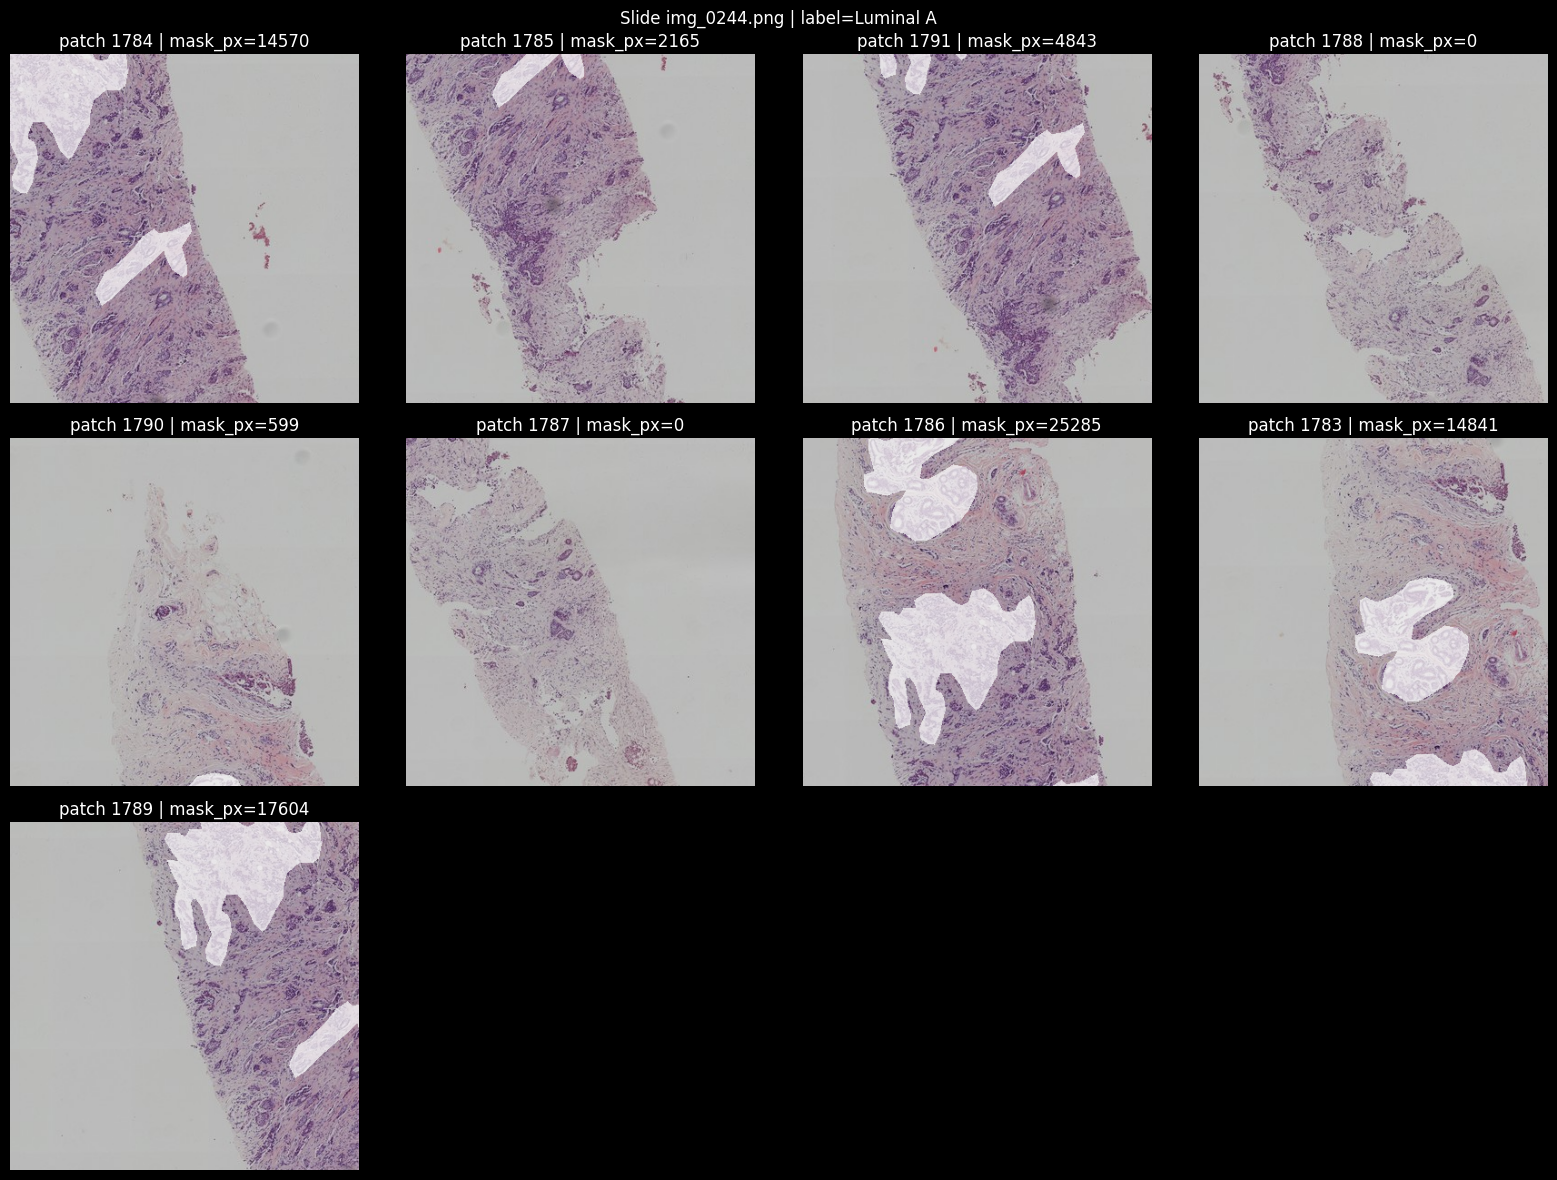

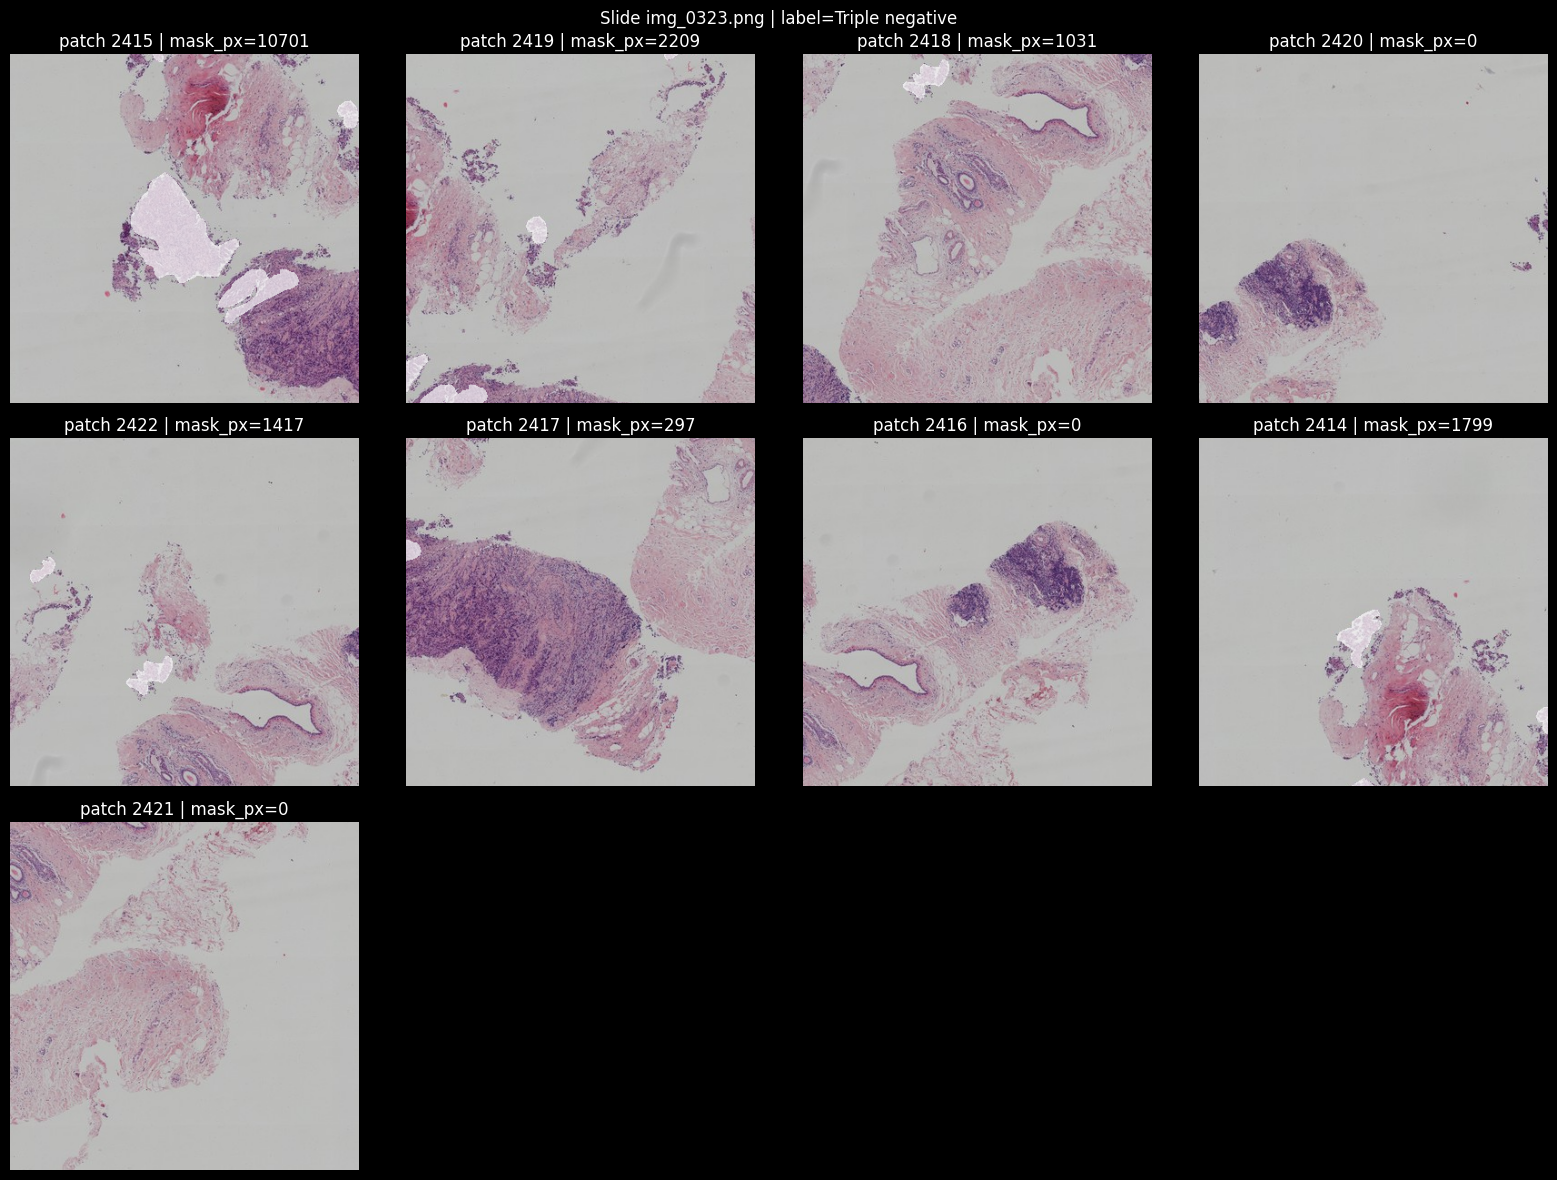

In [7]:
def show_slide_patches(slide_idx, k=12):
    start, end = slide_to_patchidx[slide_idx]
    idxs = np.arange(start, end)
    if len(idxs) == 0:
        print("No patches for slide", slide_idx)
        return
    choose = np.random.choice(idxs, size=min(k, len(idxs)), replace=False)

    n = len(choose)
    cols = 4
    rows = (n + cols - 1) // cols

    plt.figure(figsize=(4*cols, 4*rows))
    for i, pidx in enumerate(choose):
        img = X[pidx]
        msk = M[pidx, :, :, 0]

        # overlay mask (white) on image
        overlay = img.copy()
        overlay[msk > 0] = np.clip(overlay[msk > 0] * 0.3 + 255 * 0.7, 0, 255).astype(np.uint8)

        ax = plt.subplot(rows, cols, i+1)
        ax.imshow(overlay)
        ax.set_title(f"patch {pidx} | mask_px={int((msk>0).sum())}")
        ax.axis("off")

    plt.suptitle(f"Slide {df['sample_index'].iloc[slide_idx]} | label={ID2CLASS[int(y[slide_idx])]}")
    out_path = os.path.join("processed", "patches")
    os.makedirs(out_path, exist_ok=True)
    plt.savefig(os.path.join(out_path, f"patch_{df['sample_index'].iloc[slide_idx]}"))
    plt.tight_layout()
    plt.show()

for _ in range(3):
    s = np.random.randint(0, len(slide_to_patchidx))
    show_slide_patches(s, k=N_PATCHES)

In [8]:
def _save_slide_fig(slide_idx, k, x_path, m_path, patch_size, total_patches,
                    idx_path, y_path, df_sample_index, out_dir):
    import matplotlib
    matplotlib.use("Agg")

    slide_to_patchidx = np.load(idx_path)  # small
    y = np.load(y_path)

    X = np.memmap(x_path, dtype=np.uint8, mode="r",
                  shape=(total_patches, patch_size, patch_size, 3))
    M = np.memmap(m_path, dtype=np.uint8, mode="r",
                  shape=(total_patches, patch_size, patch_size, 1))

    start, end = slide_to_patchidx[slide_idx]
    idxs = np.arange(start, end)
    if len(idxs) == 0:
        return slide_idx, "empty"

    rng = np.random.default_rng(slide_idx)
    choose = rng.choice(idxs, size=min(k, len(idxs)), replace=False)

    n = len(choose)
    cols = 4
    rows = (n + cols - 1) // cols

    plt.figure(figsize=(4*cols, 4*rows))
    for i, pidx in enumerate(choose):
        img = X[pidx]
        msk = M[pidx, :, :, 0]
        overlay = img.copy()
        overlay[msk > 0] = np.clip(overlay[msk > 0] * 0.3 + 255 * 0.7, 0, 255).astype(np.uint8)

        ax = plt.subplot(rows, cols, i+1)
        ax.imshow(overlay)
        ax.set_title(f"patch {pidx} | mask_px={int((msk>0).sum())}")
        ax.axis("off")

    slide_name = df_sample_index[slide_idx]
    os.makedirs(out_dir, exist_ok=True)
    out_path = os.path.join(out_dir, f"patch_{slide_name}")
    plt.savefig(out_path, dpi=120)
    plt.close("all")
    return slide_idx, "ok"

df_sample_index = df["sample_index"].tolist()
out_dir = os.path.join("processed", "patches")

shutil.rmtree(out_dir, ignore_errors=True)

with ProcessPoolExecutor(max_workers=os.cpu_count()//2 or 4) as ex:
    futures = [
        ex.submit(_save_slide_fig, i, N_PATCHES,
                  x_path, m_path, PATCH_SIZE, total_patches,
                  idx_path, y_path, df_sample_index, out_dir)
        for i in range(len(slide_to_patchidx))
    ]

    for fut in tqdm(as_completed(futures), total=len(futures), desc="Saving previews", unit="slide"):
        fut.result()


Saving previews: 100%|██████████| 581/581 [00:42<00:00, 13.74slide/s]


In [9]:
def patch_stats(
    X, M, tmask_fn,
    num_random=5000,
    patch_size=384,
):
    """
    X: memmap [N, H, W, 3]
    M: memmap [N, H, W, 1]
    tmask_fn: function(rgb_patch) -> binary tissue mask
              (use the SAME logic as extraction)
    """
    total = X.shape[0]
    idxs = np.random.choice(total, size=min(num_random, total), replace=False)

    mask_px = []
    mask_frac = []
    tissue_frac = []
    gray_std = []

    for p in tqdm(idxs):
        img = X[p].astype(np.float32)
        msk = M[p, :, :, 0] > 0

        # --- mask stats ---
        mp = msk.sum()
        mask_px.append(mp)
        mask_frac.append(mp / (patch_size * patch_size))

        # --- tissue stats ---
        tmask = tmask_fn(img)
        tissue_frac.append(tmask.mean())

        # --- signal quality ---
        gray = img.mean(axis=2)
        gray_std.append(gray.std())

    mask_px = np.asarray(mask_px)
    mask_frac = np.asarray(mask_frac)
    tissue_frac = np.asarray(tissue_frac)
    gray_std = np.asarray(gray_std)

    print("\nMask presence:")
    print(f"  % patches with any mask: {(mask_px > 0).mean():.3f}")
    print(f"  % strong mask (>5% area): {(mask_frac > 0.05).mean():.3f}")

    print("\nMask fraction distribution:")
    for q in [0, 10, 25, 50, 75, 90, 95]:
        print(f"  p{q:02d}: {np.percentile(mask_frac, q):.4f}")

    print("\nTissue fraction distribution:")
    for q in [0, 10, 25, 50, 75, 90]:
        print(f"  p{q:02d}: {np.percentile(tissue_frac, q):.3f}")

    print("\nSignal quality:")
    print(f"  % low-contrast (std < 5): {(gray_std < 5).mean():.3f}")
    print(f"  gray std median: {np.median(gray_std):.2f}")

patch_stats(
    X=X,
    M=M,
    tmask_fn=tissue_mask_from_rgb_lab,
    patch_size=PATCH_SIZE
)

100%|██████████| 5000/5000 [00:57<00:00, 86.34it/s]


Mask presence:
  % patches with any mask: 0.766
  % strong mask (>5% area): 0.255

Mask fraction distribution:
  p00: 0.0000
  p10: 0.0000
  p25: 0.0010
  p50: 0.0190
  p75: 0.0507
  p90: 0.1116
  p95: 0.1598

Tissue fraction distribution:
  p00: 0.000
  p10: 0.000
  p25: 0.000
  p50: 0.000
  p75: 0.000
  p90: 0.000

Signal quality:
  % low-contrast (std < 5): 0.000
  gray std median: 19.08
